<a href="https://colab.research.google.com/github/Kanackle/SQLsales-analytics/blob/main/northwind_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import csv
from matplotlib import pyplot as plt
import matplotlib.cm as cm

In [35]:
#Upload orders, orderdetails, customers, and products csv files
ord = pd.read_csv("orders.csv")
od = pd.read_csv("orderdetails.csv")
cust = pd.read_csv("customers.csv")
prod = pd.read_csv("products.csv")

In [36]:
print(ord.head())
print(od.head())
print(cust.head())
print(prod.head())

   OrderID CustomerID  EmployeeID            OrderDate         RequiredDate  \
0    10248      VINET           5  1996-07-04 00:00:00  1996-08-01 00:00:00   
1    10249      TOMSP           6  1996-07-05 00:00:00  1996-08-16 00:00:00   
2    10250      HANAR           4  1996-07-08 00:00:00  1996-08-05 00:00:00   
3    10251      VICTE           3  1996-07-08 00:00:00  1996-08-05 00:00:00   
4    10252      SUPRD           4  1996-07-09 00:00:00  1996-08-06 00:00:00   

           ShippedDate  ShipVia  Freight                   ShipName  \
0  1996-07-16 00:00:00        3    32.38  Vins et alcools Chevalier   
1  1996-07-10 00:00:00        1    11.61          Toms Spezialitten   
2  1996-07-12 00:00:00        2    65.83              Hanari Carnes   
3  1996-07-15 00:00:00        1    41.34       Victuailles en stock   
4  1996-07-11 00:00:00        2    51.30             Suprmes dlices   

            ShipAddress        ShipCity ShipRegion ShipPostalCode ShipCountry  
0    59 rue de l-A

In [37]:
#Merge the customers table with the orders table for orders_table
#Merge the products table with order details for orderDetails_table

orders_table = ord[['OrderID', 'ShippedDate', 'CustomerID']].merge(cust[['CustomerID', 'CompanyName', 'Country']], on='CustomerID')
orderDetails_table = od[['OrderID', 'ProductID', 'UnitPrice', 'Quantity', 'Discount']].merge(prod[['ProductID', 'ProductName']], on='ProductID')

In [38]:
#print(orders_table.head(11))
#print(orderDetails_table.head(11))
print(orders_table.tail(11))
print(orderDetails_table.tail(11))
print(len(orders_table))
print(len(ord))

     OrderID          ShippedDate CustomerID                 CompanyName  \
819    11067  1998-05-06 00:00:00      DRACD    Drachenblut Delikatessen   
820    11068                  NaN      QUEEN               Queen Cozinha   
821    11069  1998-05-06 00:00:00      TORTU         Tortuga Restaurante   
822    11070                  NaN      LEHMS         Lehmanns Marktstand   
823    11071                  NaN      LILAS           LILA-Supermercado   
824    11072                  NaN      ERNSH                Ernst Handel   
825    11073                  NaN      PERIC    Pericles Comidas clsicas   
826    11074                  NaN      SIMOB               Simons bistro   
827    11075                  NaN      RICSU          Richter Supermarkt   
828    11076                  NaN      BONAP                    Bon app'   
829    11077                  NaN      RATTC  Rattlesnake Canyon Grocery   

         Country  
819      Germany  
820       Brazil  
821       Mexico  
822      Ge

In [39]:
#Add Revenue column to the table by using the apply function

orderDetails_table['Revenue'] = orderDetails_table.apply(
  lambda row: row['UnitPrice'] * row['Quantity'] * (1-row['Discount']),
  axis = 1
)

In [40]:
#Reorder the columns
orderDetails_table = orderDetails_table[['OrderID', 'ProductID', 'ProductName', 'UnitPrice', 'Quantity', 'Discount', 'Revenue']]
print(orderDetails_table.head(15))

    OrderID  ProductID                       ProductName  UnitPrice  Quantity  \
0     10248         11                    Queso Cabrales       14.0        12   
1     10248         42     Singaporean Hokkien Fried Mee        9.8        10   
2     10248         72            Mozzarella di Giovanni       34.8         5   
3     10249         14                              Tofu       18.6         9   
4     10249         51             Manjimup Dried Apples       42.4        40   
5     10250         41   Jack's New England Clam Chowder        7.7        10   
6     10250         51             Manjimup Dried Apples       42.4        35   
7     10250         65  Louisiana Fiery Hot Pepper Sauce       16.8        15   
8     10251         22                 Gustaf's Knckebrd       16.8         6   
9     10251         57                    Ravioli Angelo       15.6        15   
10    10251         65  Louisiana Fiery Hot Pepper Sauce       16.8        20   
11    10252         20      

In [41]:
# Step 1: Group OrderDetails by OrderID and sum the revenue
revenue_per_order = orderDetails_table.groupby('OrderID')['Revenue'].sum().reset_index()

# Step 2: Merge it into Orders_table
orders_table = orders_table.merge(revenue_per_order, on='OrderID', how='left')

In [42]:
print(orders_table.head(15))

    OrderID          ShippedDate CustomerID                 CompanyName  \
0     10248  1996-07-16 00:00:00      VINET   Vins et alcools Chevalier   
1     10249  1996-07-10 00:00:00      TOMSP           Toms Spezialitten   
2     10250  1996-07-12 00:00:00      HANAR               Hanari Carnes   
3     10251  1996-07-15 00:00:00      VICTE        Victuailles en stock   
4     10252  1996-07-11 00:00:00      SUPRD              Suprmes dlices   
5     10253  1996-07-16 00:00:00      HANAR               Hanari Carnes   
6     10254  1996-07-23 00:00:00      CHOPS           Chop-suey Chinese   
7     10255  1996-07-15 00:00:00      RICSU          Richter Supermarkt   
8     10256  1996-07-17 00:00:00      WELLI      Wellington Importadora   
9     10257  1996-07-22 00:00:00      HILAA            HILARION-Abastos   
10    10258  1996-07-23 00:00:00      ERNSH                Ernst Handel   
11    10259  1996-07-25 00:00:00      CENTC  Centro comercial Moctezuma   
12    10260  1996-07-29 0

In [43]:
#two tables - one for company, the other for country
#Group by company/country for revenue sum
revenue_per_company = orders_table.groupby('CompanyName')['Revenue'].sum().reset_index()
revenue_per_country = orders_table.groupby('Country')['Revenue'].sum().reset_index()
print(revenue_per_company.head(15))
print(revenue_per_country.head(15))

                           CompanyName   Revenue
0                  Alfreds Futterkiste   4596.20
1   Ana Trujillo Emparedados y helados   1402.95
2               Antonio Moreno Taquera   7515.35
3                      Around the Horn  13806.50
4                        B's Beverages   6089.90
5                    Berglunds snabbkp  26968.15
6              Blauer See Delikatessen   3239.80
7             Blido Comidas preparadas   5297.80
8              Blondesddsl pre et fils  19088.00
9                             Bon app'  23850.95
10               Bottom-Dollar Markets  22607.70
11          Cactus Comidas para llevar   1814.80
12          Centro comercial Moctezuma    100.80
13                   Chop-suey Chinese  12886.30
14                     Comrcio Mineiro   3810.75
      Country    Revenue
0   Argentina    8119.10
1     Austria  139496.63
2     Belgium   35134.98
3      Brazil  114968.48
4      Canada   55334.10
5     Denmark   34782.25
6     Finland   19778.45
7      France   

In [44]:
revenue_per_company = revenue_per_company.sort_values(by='Revenue', ascending=False)
revenue_per_country = revenue_per_country.sort_values(by='Revenue', ascending=False)
print(revenue_per_company)
print(revenue_per_country)

                      CompanyName    Revenue
59                     QUICK-Stop  117483.39
69             Save-a-lot Markets  115673.39
20                   Ernst Handel  113236.68
36   Hungry Owl All-Night Grocers   57317.39
63     Rattlesnake Canyon Grocery   52245.90
..                            ...        ...
29           Galera del gastrnomo     836.70
52                    North/South     649.00
43  Laughing Bacchus Wine Cellars     522.50
44           Lazy K Kountry Store     357.00
12     Centro comercial Moctezuma     100.80

[89 rows x 2 columns]
        Country    Revenue
19          USA  263566.98
8       Germany  244640.63
1       Austria  139496.63
3        Brazil  114968.48
7        France   85498.76
20    Venezuela   60814.89
18           UK   60616.51
16       Sweden   59523.70
9       Ireland   57317.39
4        Canada   55334.10
2       Belgium   35134.98
5       Denmark   34782.25
17  Switzerland   32919.50
11       Mexico   24073.45
6       Finland   19778.45
15   

In [45]:
#Determining total revenue and also average revenue generated per order
Total_Revenue = revenue_per_company['Revenue'].sum()
print(Total_Revenue)
Rev_per_order = Total_Revenue / len(orders_table)
print(Rev_per_order)

1354458.59
1631.8778192771085


In [46]:
# Input field determining revenue concentration for variable amount of countries/companies
cmp = int(input("Enter number of top companies to see: "))
cty =  int(input("Enter number of top countries to see: "))

company_total = revenue_per_company.head(cmp)['Revenue'].sum()
country_total = revenue_per_country.head(cty)['Revenue'].sum()

print(f"Total revenue for top {cmp} companies: {company_total:1f}. This makes up for {(company_total/Total_Revenue)*100:1f}% of total revenue")
print(f"Total revenue for top {cty} countries: {country_total:1f}. This makes up for {(country_total/Total_Revenue)*100:1f}% of total revenue")

Enter number of top companies to see: 3
Enter number of top countries to see: 54
Total revenue for top 3 companies: 346393.460000. This makes up for 25.574312% of total revenue
Total revenue for top 54 countries: 1354458.590000. This makes up for 100.000000% of total revenue


In [47]:
#Count how many times each company placed orders
company_counts = orders_table['CompanyName'].value_counts().reset_index()
company_counts.columns = ['CompanyName', 'OrderCount']
company_counts

,CompanyName,OrderCount
0,Save-a-lot Markets,31
1,Ernst Handel,30
2,QUICK-Stop,28
3,Hungry Owl All-Night Grocers,19
4,Folk och f HB,19
...,...,...
84,North/South,3
85,France restauration,3
86,GROSELLA-Restaurante,2
87,Lazy K Kountry Store,2


In [48]:
#Compare overall revenue alongside order count
revenue_per_company = revenue_per_company.merge(company_counts, on='CompanyName', how='left')
revenue_per_company

,CompanyName,Revenue,OrderCount
0,QUICK-Stop,117483.39,28
1,Save-a-lot Markets,115673.39,31
2,Ernst Handel,113236.68,30
3,Hungry Owl All-Night Grocers,57317.39,19
4,Rattlesnake Canyon Grocery,52245.90,18
...,...,...,...
84,Galera del gastrnomo,836.70,5
85,North/South,649.00,3
86,Laughing Bacchus Wine Cellars,522.50,3
87,Lazy K Kountry Store,357.00,2


In [49]:
#Detailed table showing overall revenue, order count and avg rev per order
revenue_per_company["AvgRevPerOrder"] = revenue_per_company.apply(lambda row: row["Revenue"] / row["OrderCount"], axis=1)
revenue_per_company

,CompanyName,Revenue,OrderCount,AvgRevPerOrder
0,QUICK-Stop,117483.39,28,4195.835357
1,Save-a-lot Markets,115673.39,31,3731.399677
2,Ernst Handel,113236.68,30,3774.556000
3,Hungry Owl All-Night Grocers,57317.39,19,3016.704737
4,Rattlesnake Canyon Grocery,52245.90,18,2902.550000
...,...,...,...,...
84,Galera del gastrnomo,836.70,5,167.340000
85,North/South,649.00,3,216.333333
86,Laughing Bacchus Wine Cellars,522.50,3,174.166667
87,Lazy K Kountry Store,357.00,2,178.500000


In [50]:
#Show which country were the most orders originated from
country_count = orders_table['Country'].value_counts().reset_index()
country_count.columns = ['Country', 'OrderCount']
country_count

,Country,OrderCount
0,Germany,122
1,USA,122
2,Brazil,83
3,France,77
4,UK,56
5,Venezuela,46
6,Austria,40
7,Sweden,37
8,Canada,30
9,Mexico,28


In [51]:
#Revenue concentration per country
revenue_per_country = revenue_per_country.merge(country_count, on="Country", how="left")
revenue_per_country

,Country,Revenue,OrderCount
0,USA,263566.98,122
1,Germany,244640.63,122
2,Austria,139496.63,40
3,Brazil,114968.48,83
4,France,85498.76,77
5,Venezuela,60814.89,46
6,UK,60616.51,56
7,Sweden,59523.70,37
8,Ireland,57317.39,19
9,Canada,55334.10,30


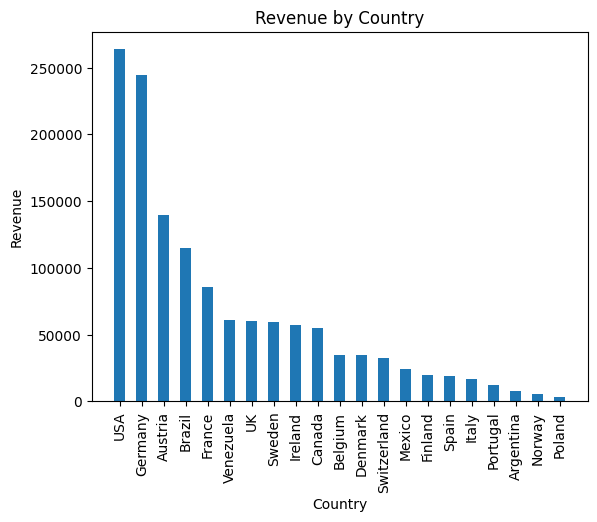

In [52]:
fig, ax = plt.subplots()
ax.bar(revenue_per_country['Country'], revenue_per_country['Revenue'], width=0.5)
ax.set_xlabel('Country')
ax.set_ylabel('Revenue')
ax.set_title('Revenue by Country')
plt.xticks(rotation=90)
plt.show()

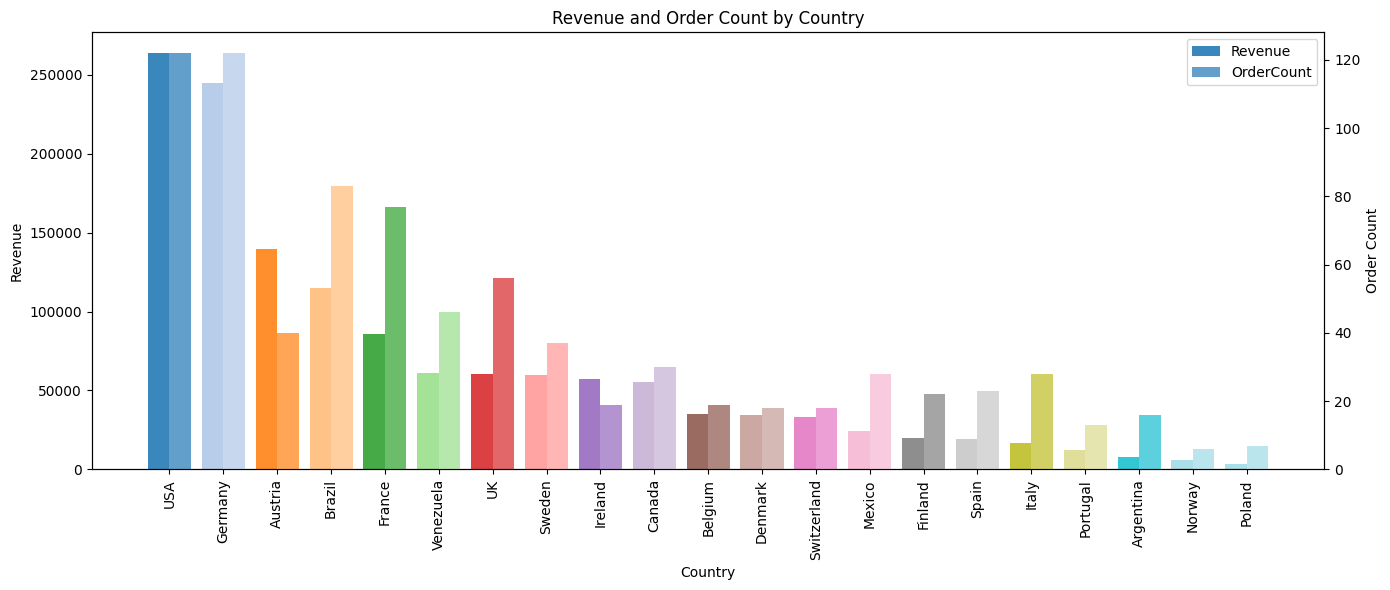

In [53]:
fig, ax1 = plt.subplots(figsize=(14, 6))

x = np.arange(len(revenue_per_country['Country']))
width = 0.4

# Generate colors
colors1 = cm.tab20(np.linspace(0, 1, len(revenue_per_country)))

# First y-axis - Revenue bars
ax2 = ax1.twinx()  # creates second y-axis sharing the same x-axis

bars1 = ax1.bar(x - width/2, revenue_per_country['Revenue'], width=width, color=colors1, alpha=0.88, label='Revenue')
bars2 = ax2.bar(x + width/2, revenue_per_country['OrderCount'], width=width, color=colors1, alpha=0.70, label='OrderCount')

# Labels and title
ax1.set_xlabel('Country')
ax1.set_ylabel('Revenue', color='black')
ax2.set_ylabel('Order Count', color='black')
ax1.set_title('Revenue and Order Count by Country')

# X tick labels
ax1.set_xticks(x)
ax1.set_xticklabels(revenue_per_country['Country'], rotation=90)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

In [54]:
#Detailed view - overall revenue, order count and avg rev per order
revenue_per_country["AvgRevPerOrder"] = revenue_per_country.apply(lambda row: row["Revenue"] / row["OrderCount"], axis=1)
revenue_per_country

,Country,Revenue,OrderCount,AvgRevPerOrder
0,USA,263566.98,122,2160.385082
1,Germany,244640.63,122,2005.251066
2,Austria,139496.63,40,3487.415750
3,Brazil,114968.48,83,1385.162410
4,France,85498.76,77,1110.373506
5,Venezuela,60814.89,46,1322.062826
6,UK,60616.51,56,1082.437679
7,Sweden,59523.70,37,1608.748649
8,Ireland,57317.39,19,3016.704737
9,Canada,55334.10,30,1844.470000


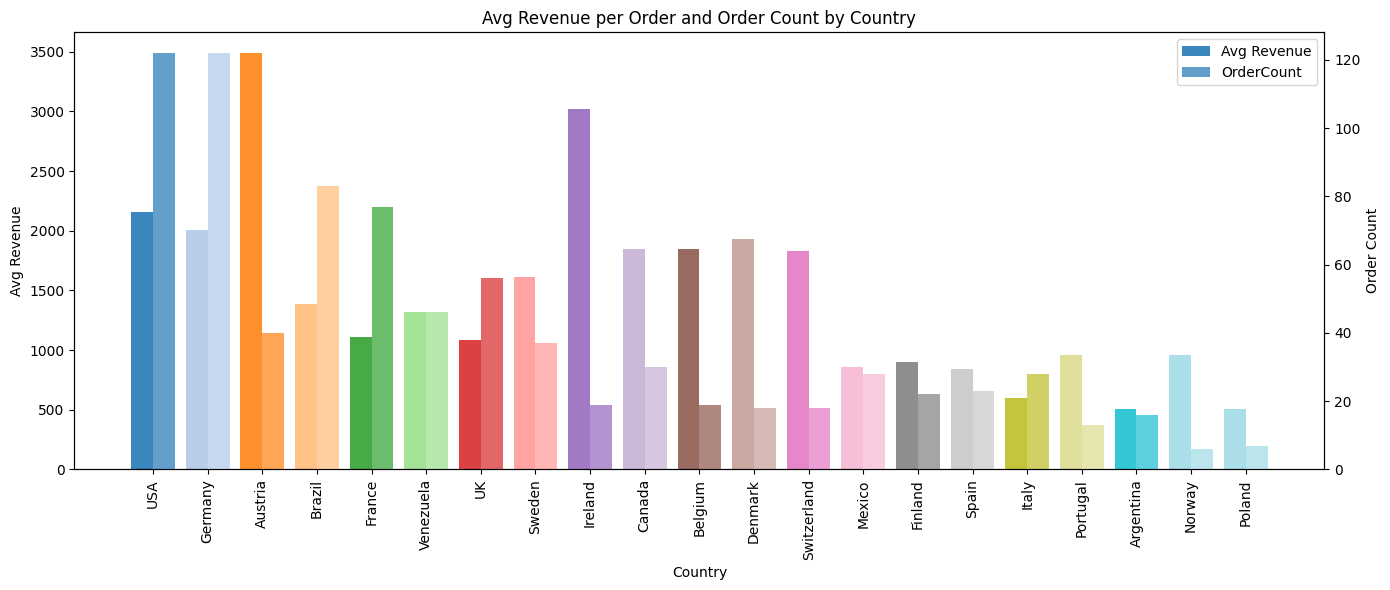

In [55]:
fig, ax1 = plt.subplots(figsize=(14, 6))

x = np.arange(len(revenue_per_country['Country']))
width = 0.4

# Generate colors
colors1 = cm.tab20(np.linspace(0, 1, len(revenue_per_country)))

# First y-axis - Revenue bars
ax2 = ax1.twinx()  # creates second y-axis sharing the same x-axis

bars1 = ax1.bar(x - width/2, revenue_per_country['AvgRevPerOrder'], width=width, color=colors1, alpha=0.88, label='Avg Revenue')
bars2 = ax2.bar(x + width/2, revenue_per_country['OrderCount'], width=width, color=colors1, alpha=0.70, label='OrderCount')

# Labels and title
ax1.set_xlabel('Country')
ax1.set_ylabel('Avg Revenue', color='black')
ax2.set_ylabel('Order Count', color='black')
ax1.set_title('Avg Revenue per Order and Order Count by Country')

# X tick labels
ax1.set_xticks(x)
ax1.set_xticklabels(revenue_per_country['Country'], rotation=90)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

In [56]:
#Break down all order dates by quarters
orders_table['ShippedDate'] = pd.to_datetime(orders_table['ShippedDate'])
#Some dates have NULL, so replaced with date after last official date in data
orders_table['ShippedDate'] = orders_table['ShippedDate'].fillna(pd.Timestamp('1998-05-07'))
orders_table['Year'] = orders_table['ShippedDate'].dt.year
orders_table['Quarter'] = orders_table['ShippedDate'].dt.quarter
orders_table

,OrderID,ShippedDate,CustomerID,CompanyName,Country,Revenue,Year,Quarter
0,10248,1996-07-16,VINET,Vins et alcools Chevalier,France,440.0,1996,3
1,10249,1996-07-10,TOMSP,Toms Spezialitten,Germany,1863.4,1996,3
2,10250,1996-07-12,HANAR,Hanari Carnes,Brazil,1813.0,1996,3
3,10251,1996-07-15,VICTE,Victuailles en stock,France,670.8,1996,3
4,10252,1996-07-11,SUPRD,Suprmes dlices,Belgium,3730.0,1996,3
...,...,...,...,...,...,...,...,...
825,11073,1998-05-07,PERIC,Pericles Comidas clsicas,Mexico,300.0,1998,2
826,11074,1998-05-07,SIMOB,Simons bistro,Denmark,244.3,1998,2
827,11075,1998-05-07,RICSU,Richter Supermarkt,Switzerland,586.0,1998,2
828,11076,1998-05-07,BONAP,Bon app',France,1057.0,1998,2


In [61]:
#Order count by yearly quarters
quarterly_summary = orders_table.groupby(['Year', 'Quarter']).agg(
    OrderCount=('OrderID', 'count'),
    TotalRevenue=('Revenue', 'sum')
).reset_index()

quarterly_summary

,Year,Quarter,OrderCount,TotalRevenue
0,1996,3,61,68045.70
1,1996,4,82,142066.60
2,1997,1,92,154255.40
3,1997,2,92,154023.29
4,1997,3,105,154508.69
5,1997,4,109,186251.43
6,1998,1,178,294406.45
7,1998,2,111,200901.03


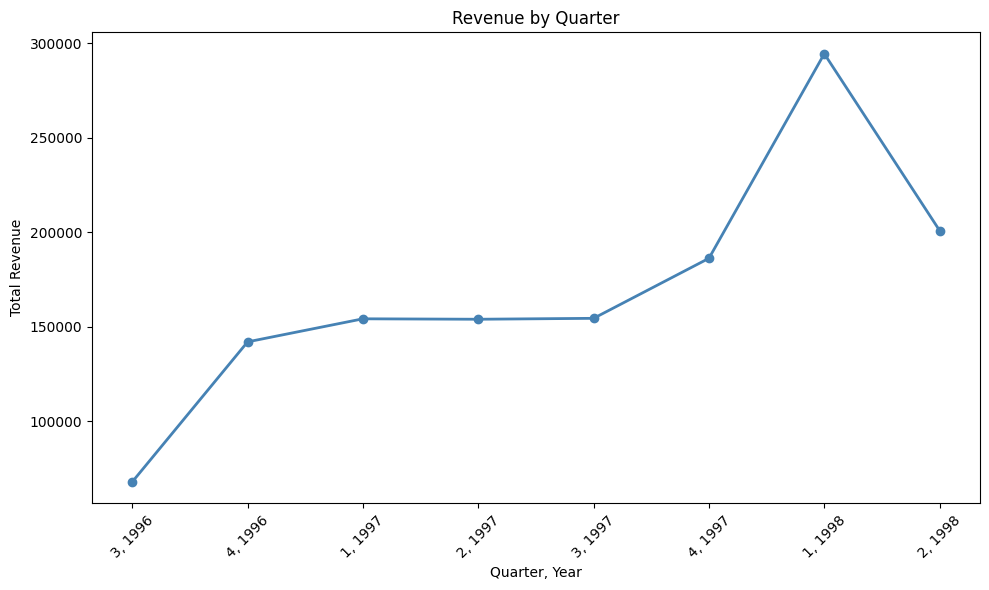

In [63]:
#To group the quarter and year together, convert the two into strings first and then concatenate them
quarterly_summary['Period'] = quarterly_summary['Quarter'].astype(str) + ', ' + quarterly_summary['Year'].astype(str)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(quarterly_summary['Period'], quarterly_summary['TotalRevenue'],
        marker='o',        # adds a dot at each data point
        linewidth=2,
        color='steelblue')

ax.set_xlabel('Quarter, Year')
ax.set_ylabel('Total Revenue')
ax.set_title('Revenue by Quarter')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
#Detailed view by yearly quarter - overall revenue, order count and avg rev per order
quarterly_summary['AvgRevPerOrder'] = quarterly_summary.apply(lambda row: row['TotalRevenue'] / row['OrderCount'], axis=1)
quarterly_summary

,Year,Quarter,OrderCount,TotalRevenue,AvgRevPerOrder
0,1996,3,61,68045.70,1115.503279
1,1996,4,82,142066.60,1732.519512
2,1997,1,92,154255.40,1676.689130
3,1997,2,92,154023.29,1674.166196
4,1997,3,105,154508.69,1471.511333
5,1997,4,109,186251.43,1708.728716
6,1998,1,178,294406.45,1653.968820
7,1998,2,111,200901.03,1809.919189


In [59]:
#Product revenue ordered by overall revenue
Revenue_by_product = orderDetails_table.groupby(['ProductName']).agg(
    TotalRev = ('Revenue', 'sum'),
    OrderCount = ('Quantity', 'sum')
).reset_index()
Revenue_by_product = Revenue_by_product.sort_values(by='TotalRev', ascending=False)
Orders_by_product = Revenue_by_product.sort_values(by='OrderCount', ascending=False)
Revenue_by_product

,ProductName,TotalRev,OrderCount
11,Cte de Blaye,149984.20,623
68,Thringer Rostbratwurst,87736.40,746
51,Raclette Courdavault,76296.00,1496
3,Camembert Pierrot,50286.00,1577
66,Tarte au sucre,49827.90,1083
...,...,...,...
33,Longlife Tofu,2566.00,297
32,Laughing Lumberjack Lager,2562.00,184
16,Genen Shouyu,1813.50,122
15,Geitost,1713.50,755


In [60]:
#Product revenue ranked by overall count
Orders_by_product

,ProductName,TotalRev,OrderCount
3,Camembert Pierrot,50286.00,1577
51,Raclette Courdavault,76296.00,1496
18,Gorgonzola Telino,16172.50,1397
17,Gnocchi di nonna Alice,45121.20,1263
46,Pavlova,18748.05,1158
...,...,...,...
32,Laughing Lumberjack Lager,2562.00,184
10,Chocolade,1542.75,138
20,Gravad lax,3047.20,125
16,Genen Shouyu,1813.50,122
